In [1]:
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..')))
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [2]:

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from src.data_handling.dataset import ECGDataset, ECGAugmentation
import torch
from src.model import (
    TransformerAutoencoder
)
from torch.utils.data import DataLoader

In [3]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd()))
ROOT_DIR = os.path.join(BASE_DIR, '..')
DATA_DIR =  os.path.join(ROOT_DIR, 'Data')

In [4]:
data_dir = os.path.join(DATA_DIR, 'input', 'preprocessed_data',"fs250_bp0.5-45Hz")
json_path = os.path.join(DATA_DIR, 'input', 'experiment', 'leads_MLII_V1_tst0.25_rd42.json')

In [5]:

# --- Set up transform ---
transform = ECGAugmentation(preset='ssl')

In [6]:
# --- Load dataset ---
dataset = ECGDataset(
    data_dir=data_dir,
    json_file_path=json_path,
    split="train",
    mode="ssl",
    window_size=256,
    transform=transform
)


dataset_no_aug = ECGDataset(  # baseline version (no transform)
    data_dir=data_dir,
    json_file_path=json_path,
    split="train",
    mode="ssl",
    window_size=256,
    transform=None
)

# --- Pick one sample ---
x_aug = dataset[0]            # augmented
x_orig = dataset_no_aug[0]


Loading data for 24 patients from 'train' split...
Loading data for 24 patients from 'train' split...


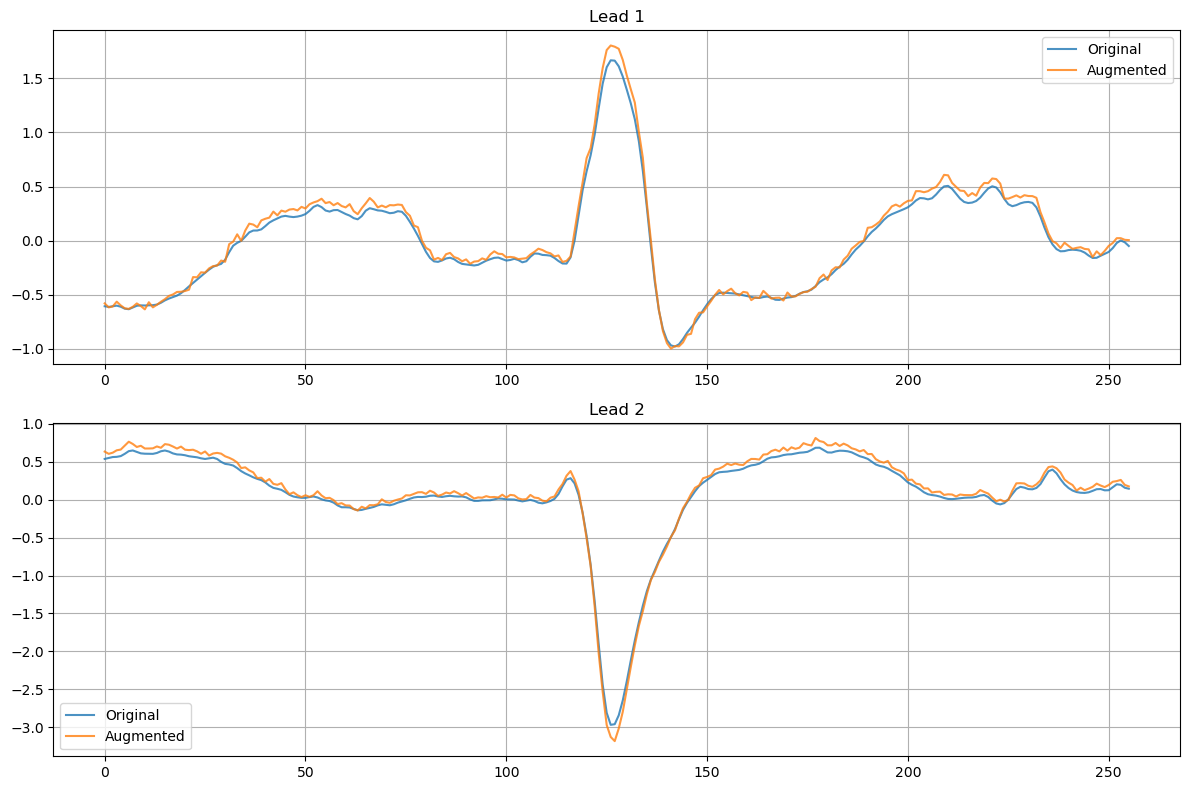

In [7]:
# --- Visualization ---
n_channels = x_orig.shape[0]
fig, axes = plt.subplots(n_channels, 1, figsize=(12, 4*n_channels))

for i in range(n_channels):
    ax = axes[i] if n_channels > 1 else axes
    ax.plot(x_orig[i].numpy(), label="Original", alpha=0.8)
    ax.plot(x_aug[i].numpy(), label="Augmented", alpha=0.8)
    ax.set_title(f"Lead {i+1}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()